<a href="https://colab.research.google.com/github/samartharora25/Sales_Forecasting/blob/main/sales_forecasting_capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🍽️ AIML Capstone – Restaurant Sales Forecasting

**Fresh Analytics** — Predicting item demand across restaurants using Data Science, Machine Learning, and Deep Learning.

---
### Datasets
- `restaurants.csv` — Restaurant IDs and names
- `items.csv` — Item metadata (store, name, kcal, cost)
- `sales.csv` — Daily sales records (date, item_id, price, item_count)

**Upload these 3 CSV files when prompted below (Colab file upload cell).**

## ⚙️ Setup & Installation

In [ ]:
# Install required libraries (run once on Colab)
!pip install xgboost --quiet

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('tab10')

print('✅ All libraries imported successfully')
print(f'TensorFlow version: {tf.__version__}')

✅ All libraries imported successfully
TensorFlow version: 2.20.0


## 📂 Upload Datasets

In [ ]:
import pandas as pd

# Assuming files are directly accessible in the current directory or /content/
restaurants = pd.read_csv('/content/resturants.csv')
items = pd.read_csv('/content/items.csv')
sales = pd.read_csv('/content/sales.csv', parse_dates=['date'])

print(f'restaurants : {restaurants.shape}')
print(f'items       : {items.shape}')
print(f'sales       : {sales.shape}')

print('\nFirst 5 rows of restaurants:')
display(restaurants.head())
print('\nFirst 5 rows of items:')
display(items.head())
print('\nFirst 5 rows of sales:')
display(sales.head())

restaurants : (6, 2)
items       : (100, 5)
sales       : (109600, 4)

First 5 rows of restaurants:


,id,name
0,1,Bob's Diner
1,2,Beachfront Bar
2,3,Sweet Shack
3,4,Fou Cher
4,5,Corner Cafe



First 5 rows of items:


,id,store_id,name,kcal,cost
0,1,4,Chocolate Cake,554,6.71
1,2,4,Breaded Fish with Vegetables Meal,772,15.09
2,3,1,Sweet Fruity Cake,931,29.22
3,4,1,Amazing Steak Dinner with Rolls,763,26.42
4,5,5,Milk Cake,583,6.07



First 5 rows of sales:


,date,item_id,price,item_count
0,2019-01-01,3,29.22,2.0
1,2019-01-01,4,26.42,22.0
2,2019-01-01,12,4.87,7.0
3,2019-01-01,13,4.18,12.0
4,2019-01-01,16,3.21,136.0


---
## 📊 Part 1 — Preliminary Analysis

### 1a. Import Datasets

In [ ]:
import pandas as pd

# The 'uploaded' dictionary is typically used with google.colab.files.upload()
# Since files are directly in /content/, we can read them directly.

restaurants = pd.read_csv('/content/resturants.csv')
items       = pd.read_csv('/content/items.csv')
sales       = pd.read_csv('/content/sales.csv', parse_dates=['date'])

print(f'restaurants : {restaurants.shape}')
print(f'items       : {items.shape}')
print(f'sales       : {sales.shape}')

restaurants : (6, 2)
items       : (100, 5)
sales       : (109600, 4)


### 1b. Shape, Structure & Outlier Check

In [ ]:
print('=== restaurants.csv ===')
display(restaurants.head())
print(restaurants.info())
print(restaurants.describe())

=== restaurants.csv ===


,id,name
0,1,Bob's Diner
1,2,Beachfront Bar
2,3,Sweet Shack
3,4,Fou Cher
4,5,Corner Cafe


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      6 non-null      int64 
 1   name    6 non-null      object
dtypes: int64(1), object(1)
memory usage: 228.0+ bytes
None
             id
count  6.000000
mean   3.500000
std    1.870829
min    1.000000
25%    2.250000
50%    3.500000
75%    4.750000
max    6.000000


In [ ]:
print('=== items.csv ===')
display(items.head())
print(items.info())
print(items.describe())
print('\nMissing values:')
print(items.isnull().sum())

=== items.csv ===


,id,store_id,name,kcal,cost
0,1,4,Chocolate Cake,554,6.71
1,2,4,Breaded Fish with Vegetables Meal,772,15.09
2,3,1,Sweet Fruity Cake,931,29.22
3,4,1,Amazing Steak Dinner with Rolls,763,26.42
4,5,5,Milk Cake,583,6.07


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        100 non-null    int64  
 1   store_id  100 non-null    int64  
 2   name      100 non-null    object 
 3   kcal      100 non-null    int64  
 4   cost      100 non-null    float64
dtypes: float64(1), int64(3), object(1)
memory usage: 4.0+ KB
None
               id    store_id         kcal        cost
count  100.000000  100.000000   100.000000  100.000000
mean    50.500000    3.520000   536.730000   11.763700
std     29.011492    1.708446   202.212852    8.991254
min      1.000000    1.000000    78.000000    1.390000
25%     25.750000    2.000000   406.250000    5.280000
50%     50.500000    4.000000   572.500000    7.625000
75%     75.250000    5.000000   638.250000   18.790000
max    100.000000    6.000000  1023.000000   53.980000

Missing values:
id          0
store_id    0
name        0
kca

In [ ]:
print('=== sales.csv ===')
display(sales.head())
print(sales.info())
print(sales.describe())
print('\nMissing values:')
print(sales.isnull().sum())
print(f'\nDate range: {sales.date.min()} → {sales.date.max()}')

=== sales.csv ===


,date,item_id,price,item_count
0,2019-01-01,3,29.22,2.0
1,2019-01-01,4,26.42,22.0
2,2019-01-01,12,4.87,7.0
3,2019-01-01,13,4.18,12.0
4,2019-01-01,16,3.21,136.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109600 entries, 0 to 109599
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   date        109600 non-null  datetime64[ns]
 1   item_id     109600 non-null  int64         
 2   price       109600 non-null  float64       
 3   item_count  109600 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1)
memory usage: 3.3 MB
None
                      date        item_id          price     item_count
count               109600  109600.000000  109600.000000  109600.000000
mean   2020-07-01 12:00:00      50.500000      11.763700       6.339297
min    2019-01-01 00:00:00       1.000000       1.390000       0.000000
25%    2019-10-01 18:00:00      25.750000       5.280000       0.000000
50%    2020-07-01 12:00:00      50.500000       7.625000       0.000000
75%    2021-04-01 06:00:00      75.250000      18.790000       0.000000
max    2021-12-31 

Outliers in item_count: 23484 rows (21.4%)


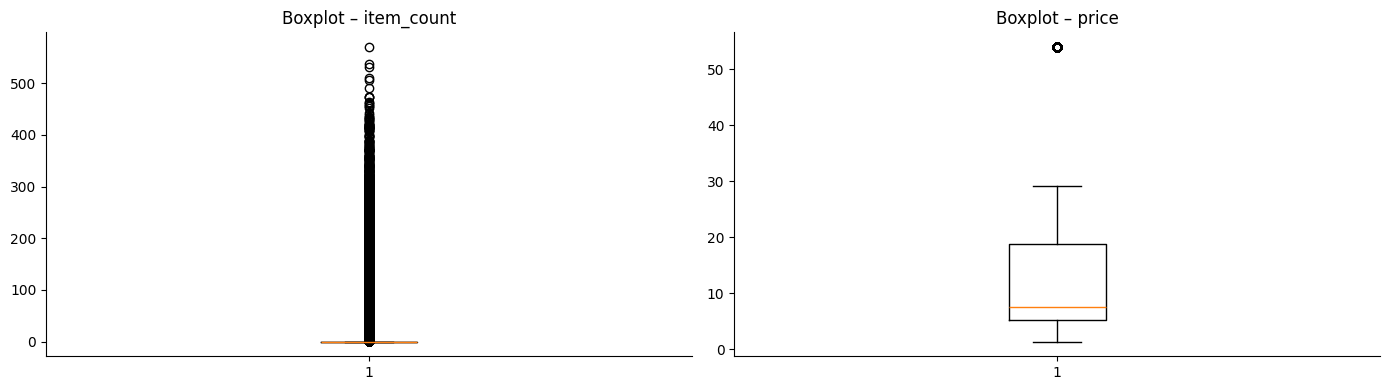

In [ ]:
# Outlier check using IQR for item_count
Q1 = sales['item_count'].quantile(0.25)
Q3 = sales['item_count'].quantile(0.75)
IQR = Q3 - Q1
outliers = sales[(sales['item_count'] < Q1 - 1.5*IQR) | (sales['item_count'] > Q3 + 1.5*IQR)]
print(f'Outliers in item_count: {len(outliers)} rows ({len(outliers)/len(sales)*100:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].boxplot(sales['item_count'].dropna())
axes[0].set_title('Boxplot – item_count')
axes[1].boxplot(sales['price'].dropna())
axes[1].set_title('Boxplot – price')
plt.tight_layout()
plt.show()

### 1c. Merge Datasets

In [ ]:
# Merge sales ← items ← restaurants
df = sales.merge(items, left_on='item_id', right_on='id', how='left')
df = df.merge(restaurants, left_on='store_id', right_on='id', how='left', suffixes=('_item', '_store'))

# Clean up columns
df.rename(columns={'name_x': 'item_name', 'name_y': 'name_store', 'id_item': 'item_uid'}, inplace=True)
df.drop(columns=['id_store'], errors='ignore', inplace=True)

# Add computed column
df['sales_amount'] = df['price'] * df['item_count']

print(f'Merged dataset shape: {df.shape}')
display(df.head(3))
print('\nColumns:', df.columns.tolist())

Merged dataset shape: (109600, 11)


,date,item_id,price,item_count,item_uid,store_id,name_item,kcal,cost,name_store,sales_amount
0,2019-01-01,3,29.22,2.0,3,1,Sweet Fruity Cake,931,29.22,Bob's Diner,58.44
1,2019-01-01,4,26.42,22.0,4,1,Amazing Steak Dinner with Rolls,763,26.42,Bob's Diner,581.24
2,2019-01-01,12,4.87,7.0,12,1,Fantastic Sweet Cola,478,4.87,Bob's Diner,34.09



Columns: ['date', 'item_id', 'price', 'item_count', 'item_uid', 'store_id', 'name_item', 'kcal', 'cost', 'name_store', 'sales_amount']


---
## 📈 Part 2 — Exploratory Data Analysis

### 2a. Date-wise Overall Sales

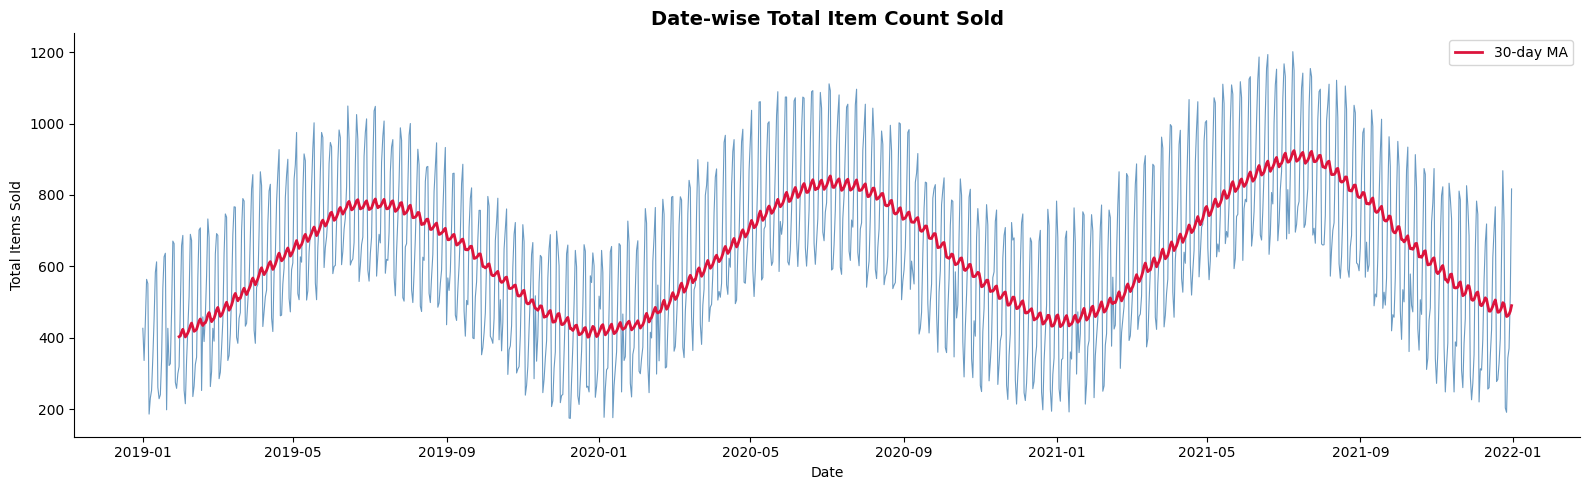

Average daily sales: 634 items
Peak sales date   : 2021-07-09 (1201 items)


In [ ]:
daily_sales = df.groupby('date')['item_count'].sum().reset_index()

plt.figure(figsize=(16, 5))
plt.plot(daily_sales['date'], daily_sales['item_count'], linewidth=0.8, color='steelblue', alpha=0.8)
# 30-day rolling average
daily_sales['rolling_30'] = daily_sales['item_count'].rolling(30).mean()
plt.plot(daily_sales['date'], daily_sales['rolling_30'], color='crimson', linewidth=2, label='30-day MA')
plt.title('Date-wise Total Item Count Sold', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Total Items Sold')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Average daily sales: {daily_sales["item_count"].mean():.0f} items')
print(f'Peak sales date   : {daily_sales.loc[daily_sales["item_count"].idxmax(), "date"].date()} '
      f'({daily_sales["item_count"].max():.0f} items)')

### 2b. Sales by Day of the Week

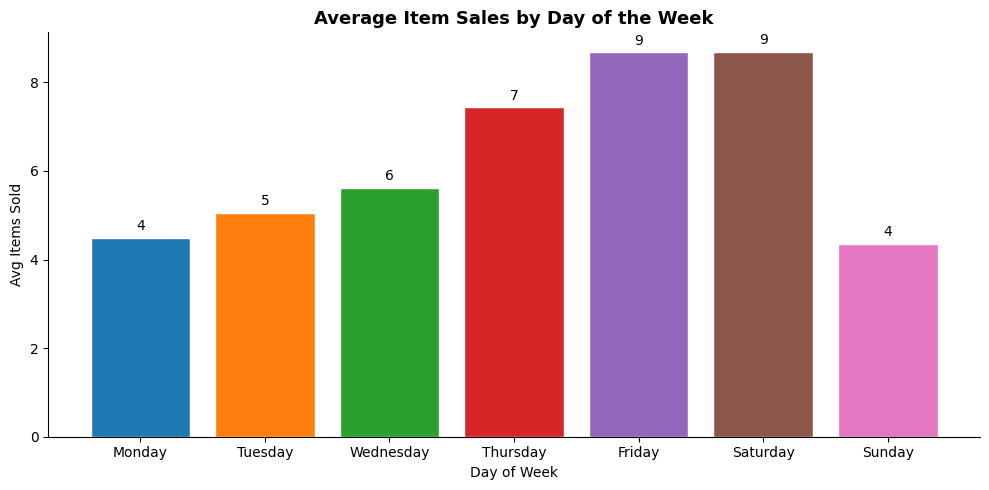

Best sales day: Saturday (9 avg items)


In [ ]:
df['day_of_week'] = df['date'].dt.day_name()
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

dow_sales = df.groupby('day_of_week')['item_count'].mean().reindex(dow_order)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(dow_sales.index, dow_sales.values, color=sns.color_palette('tab10', 7), edgecolor='white')
ax.bar_label(bars, fmt='%.0f', padding=3)
ax.set_title('Average Item Sales by Day of the Week', fontsize=13, fontweight='bold')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Avg Items Sold')
plt.tight_layout()
plt.show()

best_day = dow_sales.idxmax()
print(f'Best sales day: {best_day} ({dow_sales[best_day]:.0f} avg items)')

### 2c. Monthly Sales Trends

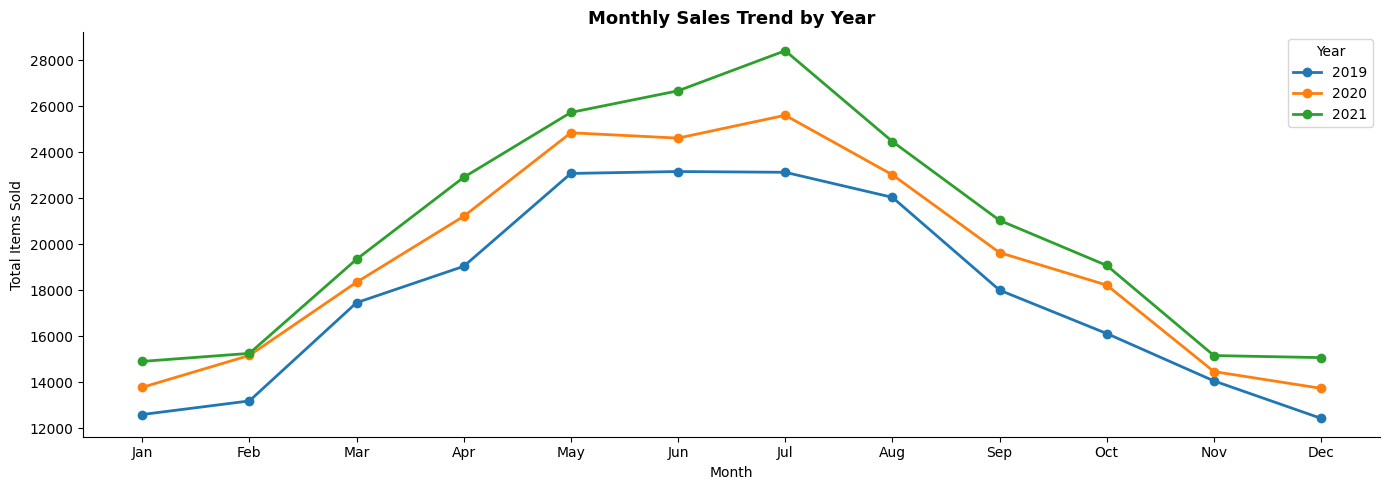

In [ ]:
df['month'] = df['date'].dt.month
df['year']  = df['date'].dt.year
month_names = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
               7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}

monthly = df.groupby(['year','month'])['item_count'].sum().reset_index()
monthly['month_name'] = monthly['month'].map(month_names)

fig, ax = plt.subplots(figsize=(14, 5))
for yr, grp in monthly.groupby('year'):
    ax.plot(grp['month'], grp['item_count'], marker='o', label=str(yr), linewidth=2)
ax.set_xticks(range(1,13))
ax.set_xticklabels(list(month_names.values()))
ax.set_title('Monthly Sales Trend by Year', fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Total Items Sold')
ax.legend(title='Year')
plt.tight_layout()
plt.show()

### 2d. Quarterly Sales Distribution (Averaged over Years)

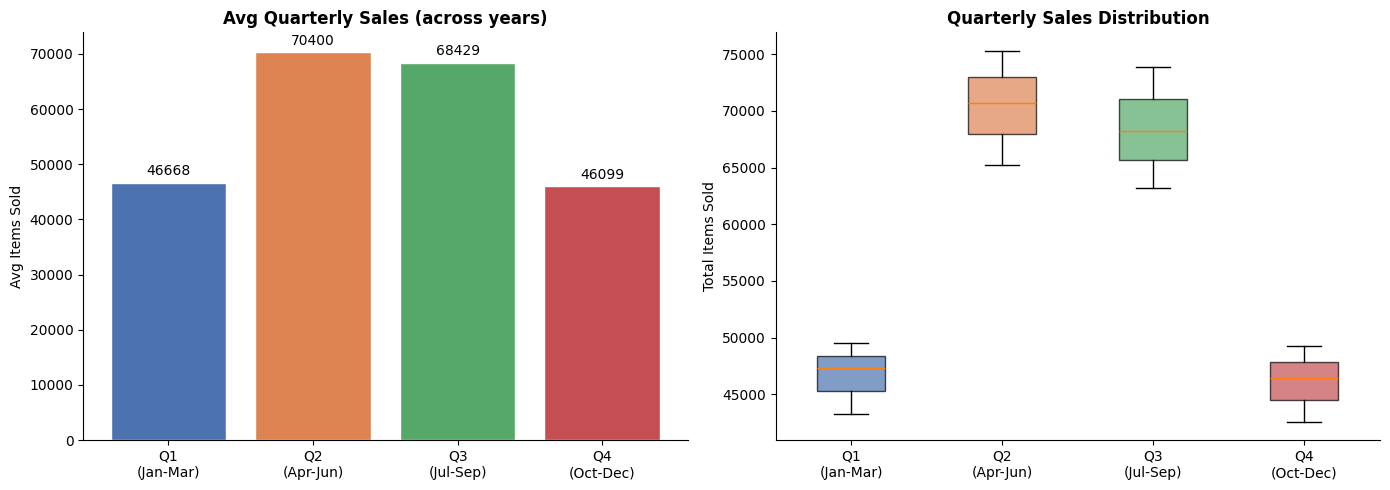

Average items sold per quarter:
  Q1 (Jan-Mar): 46,668
  Q2 (Apr-Jun): 70,400
  Q3 (Jul-Sep): 68,429
  Q4 (Oct-Dec): 46,099


In [ ]:
df['quarter'] = df['date'].dt.quarter
quarterly = df.groupby(['year','quarter'])['item_count'].sum().reset_index()
quarterly_avg = quarterly.groupby('quarter')['item_count'].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Average per quarter
q_labels = ['Q1\n(Jan-Mar)','Q2\n(Apr-Jun)','Q3\n(Jul-Sep)','Q4\n(Oct-Dec)']
bars = axes[0].bar(q_labels, quarterly_avg.values, color=['#4C72B0','#DD8452','#55A868','#C44E52'], edgecolor='white')
axes[0].bar_label(bars, fmt='%.0f', padding=3)
axes[0].set_title('Avg Quarterly Sales (across years)', fontweight='bold')
axes[0].set_ylabel('Avg Items Sold')

# Boxplot per quarter
quarterly_pivot = [quarterly[quarterly['quarter']==q]['item_count'].values for q in [1,2,3,4]]
bp = axes[1].boxplot(quarterly_pivot, labels=q_labels, patch_artist=True)
colors = ['#4C72B0','#DD8452','#55A868','#C44E52']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_title('Quarterly Sales Distribution', fontweight='bold')
axes[1].set_ylabel('Total Items Sold')

plt.tight_layout()
plt.show()

print('Average items sold per quarter:')
for q, v in zip(q_labels, quarterly_avg.values):
    print(f'  {q.replace(chr(10)," ")}: {v:,.0f}')

### 2e. Restaurant Performance Comparison

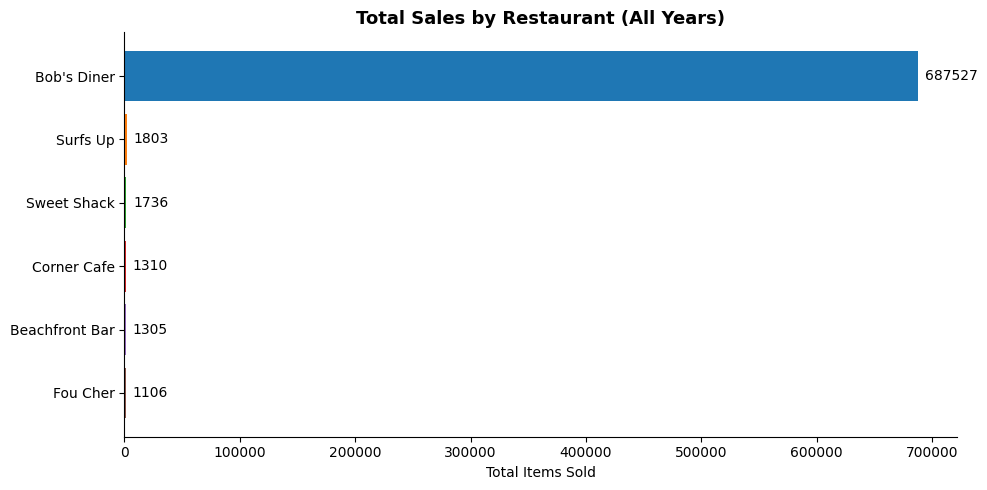

🏆 Top restaurant: Bob's Diner (687,527 items)


In [ ]:
rest_sales = df.groupby('name_store')['item_count'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(rest_sales.index, rest_sales.values, color=sns.color_palette('tab10', len(rest_sales)))
ax.bar_label(bars, fmt='%.0f', padding=5)
ax.set_title('Total Sales by Restaurant (All Years)', fontsize=13, fontweight='bold')
ax.set_xlabel('Total Items Sold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(f'🏆 Top restaurant: {rest_sales.idxmax()} ({rest_sales.max():,.0f} items)')

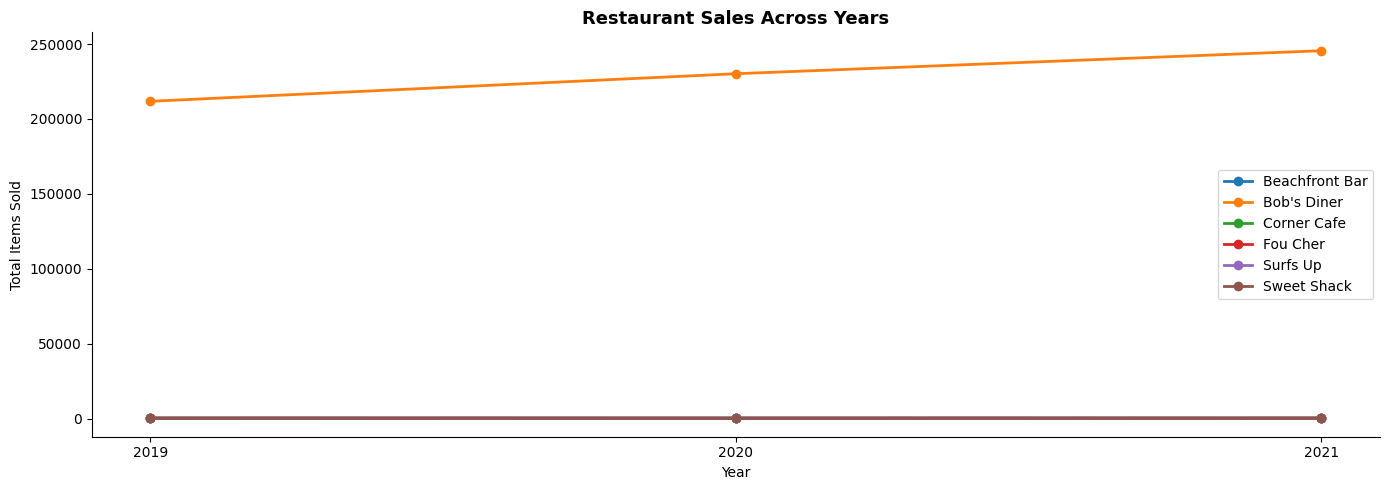

In [ ]:
# Sales by restaurant w year
rest_yearly = df.groupby(['name_store','year'])['item_count'].sum().reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
for store, grp in rest_yearly.groupby('name_store'):
    ax.plot(grp['year'], grp['item_count'], marker='o', label=store, linewidth=2)
ax.set_title('Restaurant Sales Across Years', fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Total Items Sold')
ax.set_xticks(rest_yearly['year'].unique())
ax.legend()
plt.tight_layout()
plt.show()

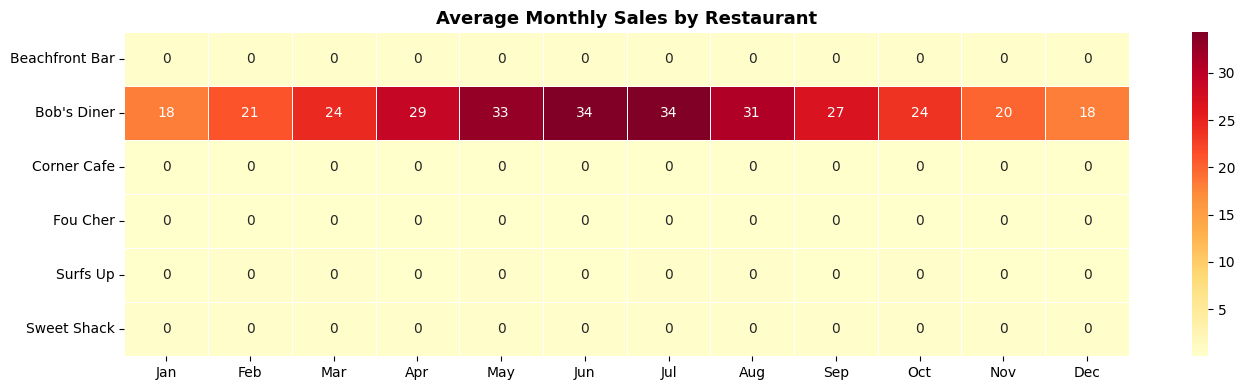

In [ ]:
# Sales by restaurant × month (heatmap)
rest_month = df.groupby(['name_store','month'])['item_count'].mean().unstack()
rest_month.columns = list(month_names.values())

plt.figure(figsize=(14, 4))
sns.heatmap(rest_month, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5)
plt.title('Average Monthly Sales by Restaurant', fontsize=13, fontweight='bold')
plt.ylabel('')
plt.tight_layout()
plt.show()

### 2f. Most Popular Items Overall & per Store

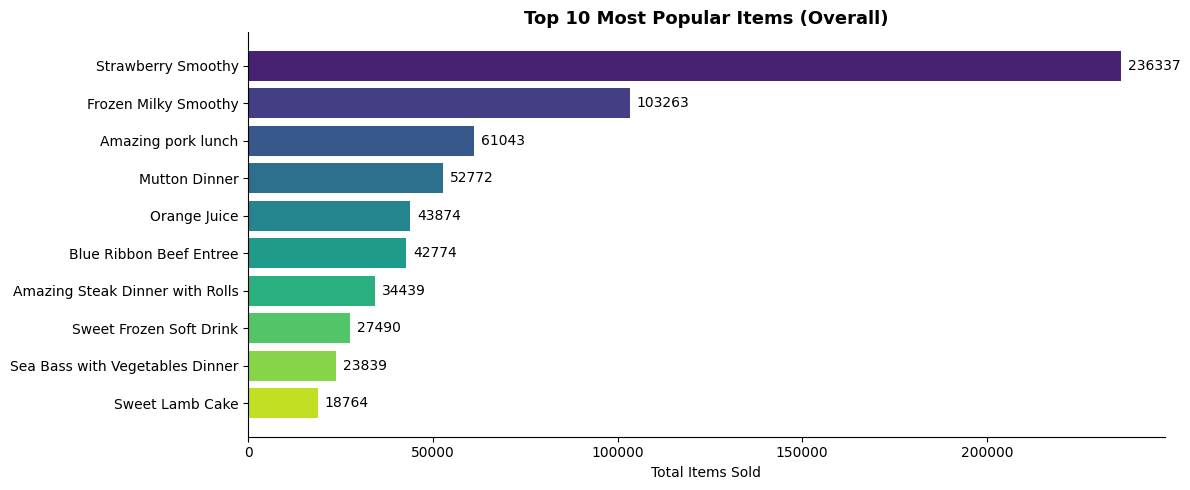

In [ ]:
# Top 10 items overall
item_sales = df.groupby(['name_item','name_store'])['item_count'].sum().reset_index()
top10 = item_sales.groupby('name_item')['item_count'].sum().nlargest(10).reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(top10['name_item'], top10['item_count'], color=sns.color_palette('viridis', 10))
ax.bar_label(bars, fmt='%.0f', padding=5)
ax.set_title('Top 10 Most Popular Items (Overall)', fontsize=13, fontweight='bold')
ax.set_xlabel('Total Items Sold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
# Most popular item per store
pop_per_store = (df.groupby(['name_store','name_item'])['item_count']
                   .sum().reset_index()
                   .sort_values('item_count', ascending=False)
                   .groupby('name_store').first().reset_index())

print('Most popular item at each restaurant:')
display(pop_per_store[['name_store','name_item','item_count']].rename(
    columns={'name_store':'Restaurant','name_item':'Top Item','item_count':'Total Sold'}))

Most popular item at each restaurant:


,Restaurant,Top Item,Total Sold
0,Beachfront Bar,Fantastic Milky Smoothy,1147.0
1,Bob's Diner,Strawberry Smoothy,236337.0
2,Corner Cafe,Frozen Milky Smoothy,273.0
3,Fou Cher,Blue Ribbon Fruity Vegi Lunch,298.0
4,Surfs Up,Awesome Soft Drink,997.0
5,Sweet Shack,Awesome Smoothy,1692.0


### 2g. Highest Sales Volume vs. Most Revenue per Day

Store Volume vs. Daily Revenue Comparison:


,Total Volume,Avg Daily Revenue ($),Volume Rank,Revenue Rank
name_store,,,,
Bob's Diner,687527.0,5782.19,1,1
Surfs Up,1803.0,14.28,2,4
Sweet Shack,1736.0,2.35,3,6
Corner Cafe,1310.0,15.10,4,3
Beachfront Bar,1305.0,3.46,5,5
Fou Cher,1106.0,25.44,6,2



🏆 Highest sales VOLUME : Bob's Diner
💰 Most daily REVENUE  : Bob's Diner

Same store? ✅ Yes


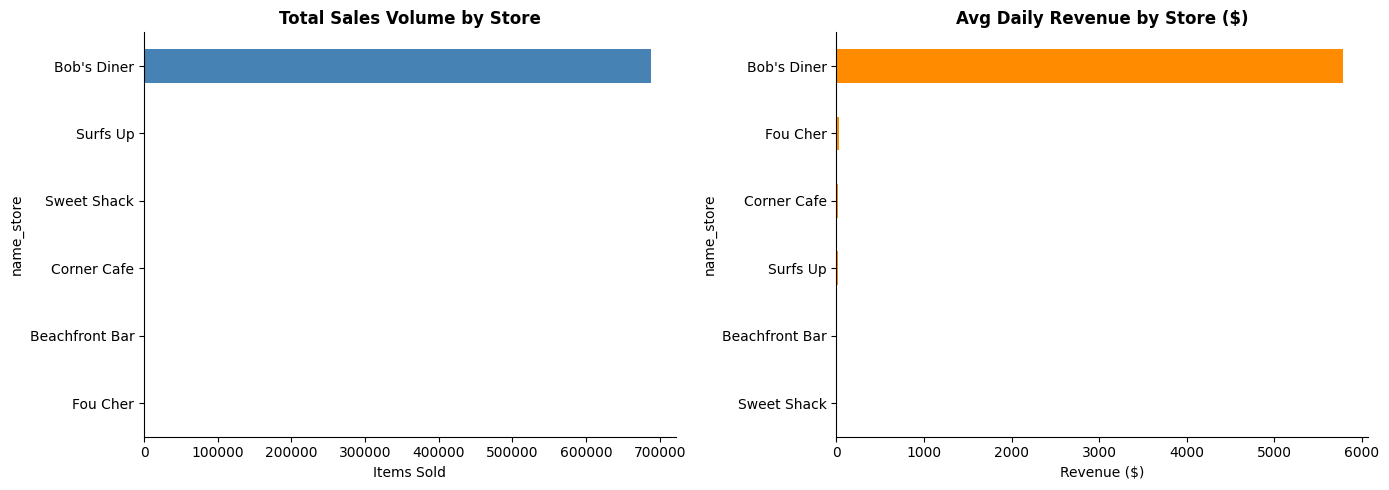

In [ ]:
store_volume  = df.groupby('name_store')['item_count'].sum()
store_revenue = df.groupby('name_store')['sales_amount'].sum()
date_count    = df['date'].nunique()

store_daily_rev = (store_revenue / date_count).round(2)

compare_df = pd.DataFrame({'Total Volume': store_volume, 'Avg Daily Revenue ($)': store_daily_rev})
compare_df['Volume Rank']  = compare_df['Total Volume'].rank(ascending=False).astype(int)
compare_df['Revenue Rank'] = compare_df['Avg Daily Revenue ($)'].rank(ascending=False).astype(int)

print('Store Volume vs. Daily Revenue Comparison:')
display(compare_df.sort_values('Volume Rank'))

top_vol = store_volume.idxmax()
top_rev = store_daily_rev.idxmax()
print(f'\n🏆 Highest sales VOLUME : {top_vol}')
print(f'💰 Most daily REVENUE  : {top_rev}')
print(f'\nSame store? {"✅ Yes" if top_vol == top_rev else "❌ No – different stores lead volume vs. revenue"}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
store_volume.sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Total Sales Volume by Store', fontweight='bold')
axes[0].set_xlabel('Items Sold')

store_daily_rev.sort_values().plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_title('Avg Daily Revenue by Store ($)', fontweight='bold')
axes[1].set_xlabel('Revenue ($)')
plt.tight_layout()
plt.show()

### 2h. Most Expensive Item at Each Restaurant & its Calorie Count

Most expensive item at each restaurant:


,Restaurant,Most Expensive Item,Price ($),Calories (kcal)
0,Beachfront Bar,Sweet Vegi Soft Drink,5.70,538
1,Bob's Diner,Sweet Fruity Cake,29.22,931
2,Corner Cafe,Pike Lunch,26.37,653
3,Fou Cher,Blue Ribbon Fruity Vegi Lunch,53.98,881
4,Surfs Up,Steak Meal,26.21,607
5,Sweet Shack,Blue Ribbon Frozen Milky Cake,7.70,636


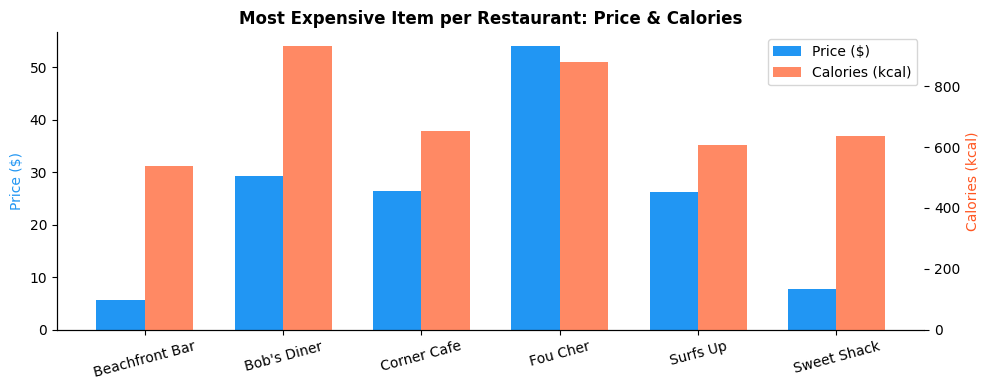

In [ ]:
# Join items with restaurant names
items_with_store = items.merge(restaurants, left_on='store_id', right_on='id', suffixes=('_item','_store'))
most_expensive = (items_with_store.sort_values('cost', ascending=False)
                                  .groupby('name_store').first().reset_index())

result_h = most_expensive[['name_store','name_item','cost','kcal']].rename(
    columns={'name_store':'Restaurant','name_item':'Most Expensive Item','cost':'Price ($)','kcal':'Calories (kcal)'})

print('Most expensive item at each restaurant:')
display(result_h)

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(result_h))
width = 0.35
b1 = ax.bar(x - width/2, result_h['Price ($)'], width, label='Price ($)', color='#2196F3')
ax2 = ax.twinx()
b2 = ax2.bar(x + width/2, result_h['Calories (kcal)'], width, label='Calories (kcal)', color='#FF5722', alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(result_h['Restaurant'], rotation=15)
ax.set_ylabel('Price ($)', color='#2196F3')
ax2.set_ylabel('Calories (kcal)', color='#FF5722')
ax.set_title('Most Expensive Item per Restaurant: Price & Calories', fontweight='bold')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1+lines2, labels1+labels2, loc='upper right')
plt.tight_layout()
plt.show()

---
## 🤖 Part 3 — Machine Learning: Sales Forecasting

### Feature Engineering

In [ ]:
# Aggregate to daily total item count
daily = df.groupby('date')['item_count'].sum().reset_index()
daily = daily.sort_values('date').reset_index(drop=True)

# Time-based features
daily['year']        = daily['date'].dt.year
daily['month']       = daily['date'].dt.month
daily['day']         = daily['date'].dt.day
daily['day_of_week'] = daily['date'].dt.dayofweek   # 0=Mon
daily['quarter']     = daily['date'].dt.quarter
daily['week']        = daily['date'].dt.isocalendar().week.astype(int)
daily['day_of_year'] = daily['date'].dt.dayofyear

# Lag features
daily['lag_7']  = daily['item_count'].shift(7)
daily['lag_14'] = daily['item_count'].shift(14)
daily['lag_30'] = daily['item_count'].shift(30)

# Rolling features
daily['rolling_7_mean']  = daily['item_count'].shift(1).rolling(7).mean()
daily['rolling_30_mean'] = daily['item_count'].shift(1).rolling(30).mean()

daily.dropna(inplace=True)
daily.reset_index(drop=True, inplace=True)

print(f'Feature dataset shape: {daily.shape}')
display(daily.head(3))

Feature dataset shape: (1066, 14)


,date,item_count,year,month,day,day_of_week,quarter,week,day_of_year,lag_7,lag_14,lag_30,rolling_7_mean,rolling_30_mean
0,2019-01-31,483.0,2019,1,31,3,1,5,31,475.0,540.0,427.0,423.571429,403.666667
1,2019-02-01,659.0,2019,2,1,4,1,5,32,671.0,627.0,337.0,424.714286,405.533333
2,2019-02-02,687.0,2019,2,2,5,1,5,33,664.0,637.0,445.0,423.000000,416.266667


In [ ]:
# Split: last 6 months = test
cutoff = daily['date'].max() - pd.DateOffset(months=6)
train = daily[daily['date'] <= cutoff]
test  = daily[daily['date'] >  cutoff]

features = ['year','month','day','day_of_week','quarter','week','day_of_year',
            'lag_7','lag_14','lag_30','rolling_7_mean','rolling_30_mean']

X_train, y_train = train[features], train['item_count']
X_test,  y_test  = test[features],  test['item_count']

print(f'Train: {train["date"].min().date()} → {train["date"].max().date()} ({len(train)} days)')
print(f'Test : {test["date"].min().date()} → {test["date"].max().date()} ({len(test)} days)')

Train: 2019-01-31 → 2021-06-30 (882 days)
Test : 2021-07-01 → 2021-12-31 (184 days)


### Linear Regression

In [ ]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)
lr_rmse  = np.sqrt(mean_squared_error(y_test, lr_preds))
print(f'Linear Regression RMSE: {lr_rmse:.2f}')

Linear Regression RMSE: 59.95


### Random Forest

In [ ]:
rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
rf_rmse  = np.sqrt(mean_squared_error(y_test, rf_preds))
print(f'Random Forest RMSE: {rf_rmse:.2f}')

Random Forest RMSE: 59.67


### XGBoost

In [ ]:
xgb = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=5,
                   subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0)
xgb.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
xgb_preds = xgb.predict(X_test)
xgb_rmse  = np.sqrt(mean_squared_error(y_test, xgb_preds))
print(f'XGBoost RMSE: {xgb_rmse:.2f}')

XGBoost RMSE: 57.83


### Model Comparison & Best Model Forecast

Model Performance (lower RMSE = better):


,Model,RMSE
2,XGBoost,57.825170
1,Random Forest,59.674783
0,Linear Regression,59.948892


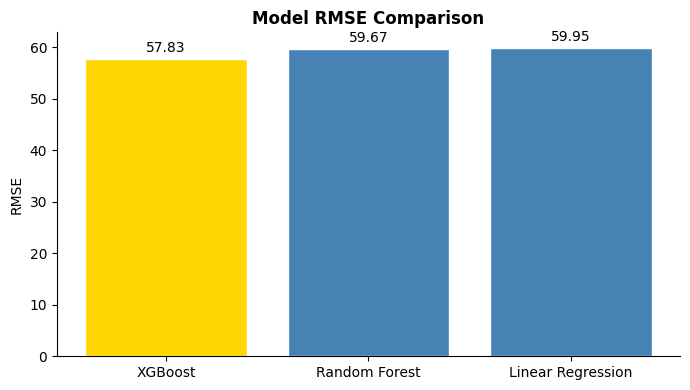


🏆 Best model: XGBoost (RMSE = 57.83)


In [ ]:
results = pd.DataFrame({
    'Model': ['Linear Regression','Random Forest','XGBoost'],
    'RMSE':  [lr_rmse, rf_rmse, xgb_rmse]
}).sort_values('RMSE')

print('Model Performance (lower RMSE = better):')
display(results)

fig, ax = plt.subplots(figsize=(7, 4))
colors = ['gold' if i==0 else 'steelblue' for i in range(len(results))]
bars = ax.bar(results['Model'], results['RMSE'], color=colors, edgecolor='white')
ax.bar_label(bars, fmt='%.2f', padding=3)
ax.set_title('Model RMSE Comparison', fontweight='bold')
ax.set_ylabel('RMSE')
plt.tight_layout()
plt.show()

best_model_name = results.iloc[0]['Model']
best_preds = {'Linear Regression': lr_preds, 'Random Forest': rf_preds, 'XGBoost': xgb_preds}[best_model_name]
print(f'\n🏆 Best model: {best_model_name} (RMSE = {results.iloc[0]["RMSE"]:.2f})')

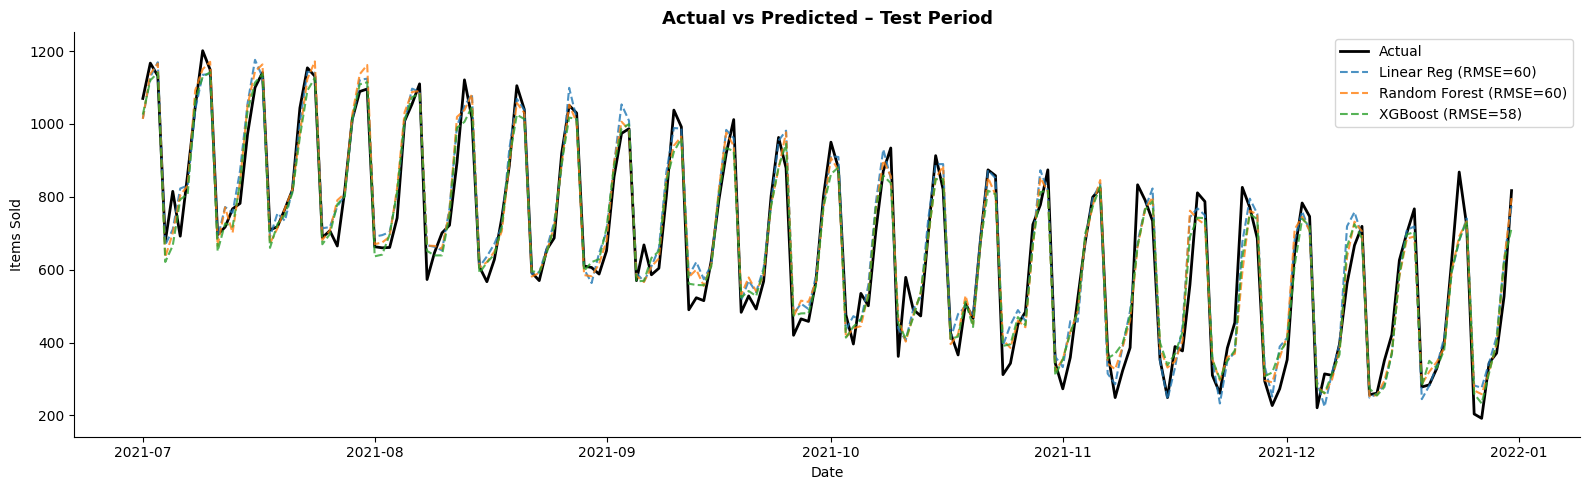

In [ ]:
# Actual vs Predicted – all 3 models
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(test['date'], y_test.values, label='Actual', color='black', linewidth=2)
ax.plot(test['date'], lr_preds,  label=f'Linear Reg (RMSE={lr_rmse:.0f})',  linestyle='--', alpha=0.8)
ax.plot(test['date'], rf_preds,  label=f'Random Forest (RMSE={rf_rmse:.0f})',  linestyle='--', alpha=0.8)
ax.plot(test['date'], xgb_preds, label=f'XGBoost (RMSE={xgb_rmse:.0f})', linestyle='--', alpha=0.8)
ax.set_title('Actual vs Predicted – Test Period', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Items Sold')
ax.legend()
plt.tight_layout()
plt.show()

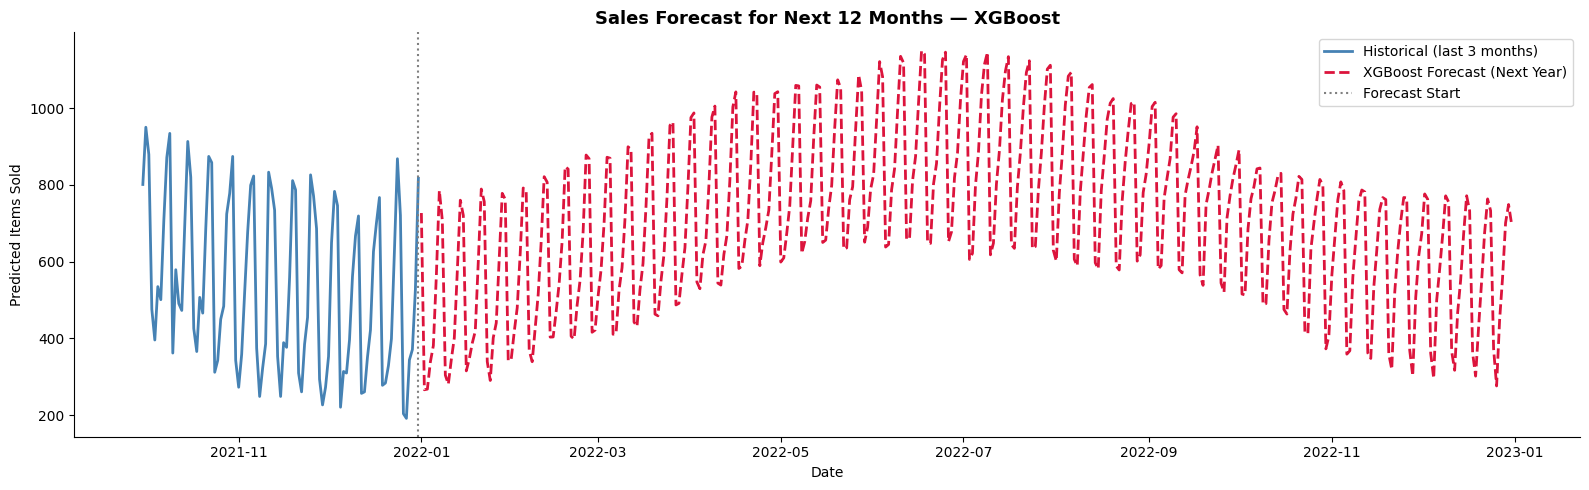

Forecasted total items for next year: 260,525


In [ ]:
# Forecast next 365 days using best model
# We'll use the XGBoost / best model iteratively with rolling lag updates
best_model = {'Linear Regression': lr, 'Random Forest': rf, 'XGBoost': xgb}[best_model_name]

last_date   = daily['date'].max()
history     = daily['item_count'].tolist()
future_dates = pd.date_range(last_date + pd.Timedelta(days=1), periods=365)
future_preds = []

for fd in future_dates:
    row = {
        'year':        fd.year,
        'month':       fd.month,
        'day':         fd.day,
        'day_of_week': fd.dayofweek,
        'quarter':     fd.quarter,
        'week':        fd.isocalendar()[1],
        'day_of_year': fd.timetuple().tm_yday,
        'lag_7':       history[-7],
        'lag_14':      history[-14],
        'lag_30':      history[-30],
        'rolling_7_mean':  np.mean(history[-7:]),
        'rolling_30_mean': np.mean(history[-30:]),
    }
    X_pred = pd.DataFrame([row])[features]
    pred   = best_model.predict(X_pred)[0]
    pred   = max(0, pred)  # no negative sales
    future_preds.append(pred)
    history.append(pred)

forecast_df = pd.DataFrame({'date': future_dates, 'forecast': future_preds})

fig, ax = plt.subplots(figsize=(16, 5))
# Last 3 months of actual
recent = daily[daily['date'] >= daily['date'].max() - pd.DateOffset(months=3)]
ax.plot(recent['date'], recent['item_count'], label='Historical (last 3 months)', color='steelblue', linewidth=2)
ax.plot(forecast_df['date'], forecast_df['forecast'], label=f'{best_model_name} Forecast (Next Year)',
        color='crimson', linewidth=2, linestyle='--')
ax.axvline(last_date, color='gray', linestyle=':', linewidth=1.5, label='Forecast Start')
ax.set_title(f'Sales Forecast for Next 12 Months — {best_model_name}', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Predicted Items Sold')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Forecasted total items for next year: {forecast_df["forecast"].sum():,.0f}')

---
## 🧠 Part 4 — Deep Learning: LSTM Sales Forecasting

### Prepare Sales Amount Time Series

Revenue series: 1096 days
Date range: 2019-01-01 → 2021-12-31
Avg daily revenue: $5,842.83


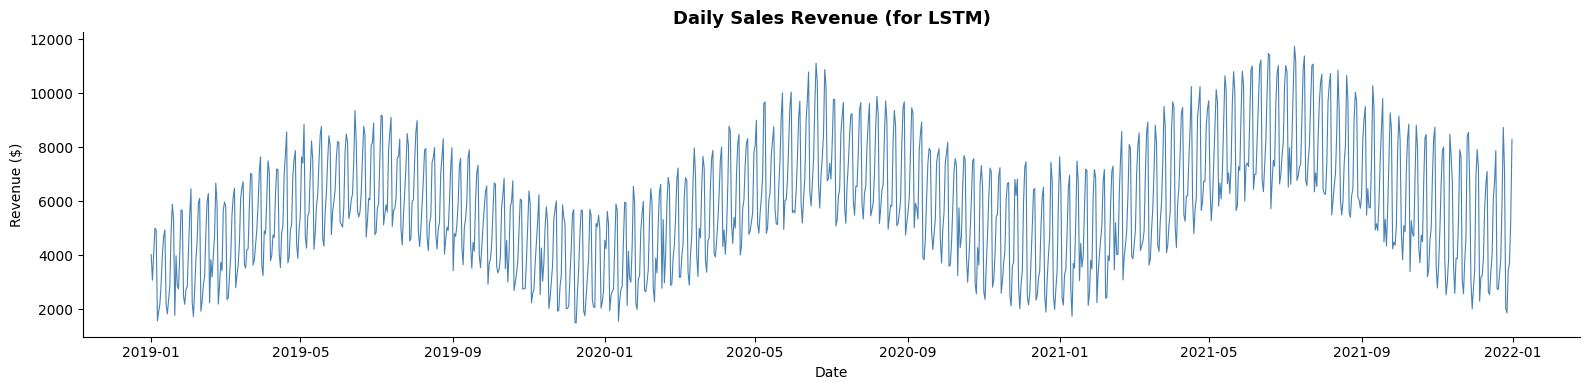

In [ ]:
# Use daily sales_amount (revenue) as the target
daily_revenue = df.groupby('date')['sales_amount'].sum().reset_index()
daily_revenue = daily_revenue.sort_values('date').reset_index(drop=True)
daily_revenue.columns = ['date', 'sales_amount']

print(f'Revenue series: {len(daily_revenue)} days')
print(f'Date range: {daily_revenue["date"].min().date()} → {daily_revenue["date"].max().date()}')
print(f'Avg daily revenue: ${daily_revenue["sales_amount"].mean():,.2f}')

plt.figure(figsize=(16, 4))
plt.plot(daily_revenue['date'], daily_revenue['sales_amount'], linewidth=0.8, color='steelblue')
plt.title('Daily Sales Revenue (for LSTM)', fontsize=13, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Revenue ($)')
plt.tight_layout()
plt.show()

### Generate Synthetic Data for Last 12 Months

Full series (actual + synthetic): 1461 days


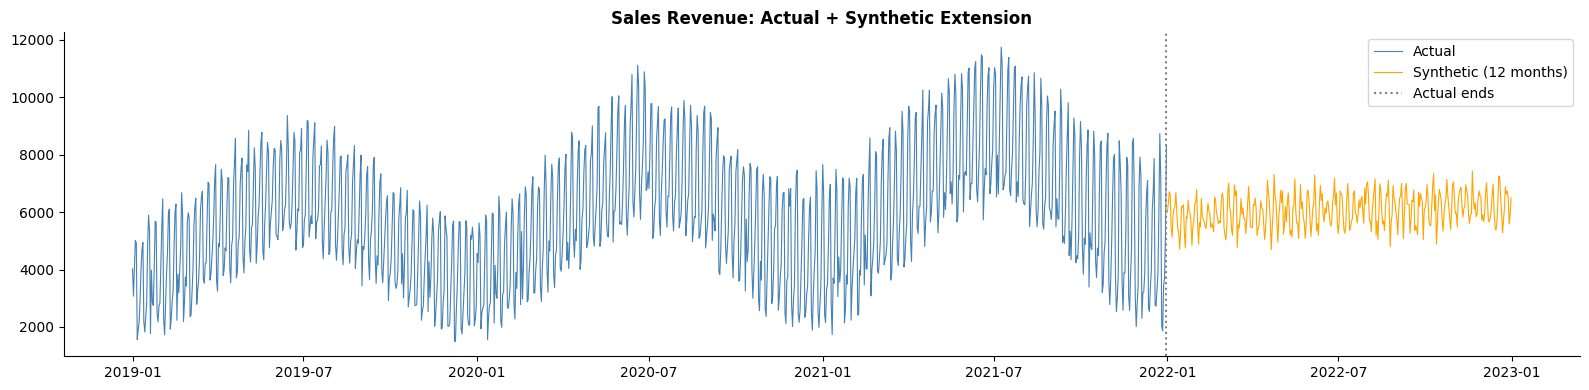

In [ ]:
# Generate 12 months of synthetic data appended to actual series
np.random.seed(42)
last_rev_date = daily_revenue['date'].max()
synth_dates = pd.date_range(last_rev_date + pd.Timedelta(days=1), periods=365)

# Estimate trend and seasonality from existing data
avg_rev = daily_revenue['sales_amount'].mean()
std_rev = daily_revenue['sales_amount'].std()

# Simulate with slight trend + weekly pattern + noise
t = np.arange(365)
weekly_pattern = np.sin(2 * np.pi * t / 7) * std_rev * 0.3
trend = t * (avg_rev * 0.0002)
noise = np.random.normal(0, std_rev * 0.15, 365)
synth_values = avg_rev + weekly_pattern + trend + noise
synth_values = np.clip(synth_values, 0, None)

synth_df = pd.DataFrame({'date': synth_dates, 'sales_amount': synth_values})

# Combine actual + synthetic
full_series = pd.concat([daily_revenue, synth_df], ignore_index=True)
print(f'Full series (actual + synthetic): {len(full_series)} days')

plt.figure(figsize=(16, 4))
plt.plot(daily_revenue['date'], daily_revenue['sales_amount'], label='Actual', color='steelblue', linewidth=0.8)
plt.plot(synth_df['date'], synth_df['sales_amount'], label='Synthetic (12 months)', color='orange', linewidth=0.8)
plt.axvline(last_rev_date, color='gray', linestyle=':', label='Actual ends')
plt.title('Sales Revenue: Actual + Synthetic Extension', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

### Build & Train LSTM Model

In [ ]:
# Scale the data
scaler = MinMaxScaler()
series_values = full_series['sales_amount'].values.reshape(-1, 1)
scaled = scaler.fit_transform(series_values)

# Define train/test split (last 12 months = synthetic = test)
n_test  = 365
n_train = len(scaled) - n_test

# Create sequences
SEQ_LEN = 30  # lookback window

def create_sequences(data, seq_len):
    X, y = [], []
    for i in range(seq_len, len(data)):
        X.append(data[i-seq_len:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X_all, y_all = create_sequences(scaled, SEQ_LEN)

# Align split with sequence offset
split_idx = n_train - SEQ_LEN
X_tr, y_tr = X_all[:split_idx], y_all[:split_idx]
X_te, y_te = X_all[split_idx:], y_all[split_idx:]

# Reshape for LSTM [samples, timesteps, features]
X_tr = X_tr.reshape(X_tr.shape[0], X_tr.shape[1], 1)
X_te = X_te.reshape(X_te.shape[0], X_te.shape[1], 1)

print(f'Train sequences: {X_tr.shape}')
print(f'Test  sequences: {X_te.shape}')

Train sequences: (1066, 30, 1)
Test  sequences: (365, 30, 1)


In [ ]:
tf.random.set_seed(42)

model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(SEQ_LEN, 1)),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 8s 63ms/step - loss: 0.0592 - val_loss: 0.0467
Epoch 2/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0322 - val_loss: 0.0430
Epoch 3/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0313 - val_loss: 0.0429
Epoch 4/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0300 - val_loss: 0.0426
Epoch 5/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0305 - val_loss: 0.0421
Epoch 6/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0293 - val_loss: 0.0419
Epoch 7/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0297 - val_loss: 0.0414
Epoch 8/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0298 - val_loss: 0.0417
Epoch 9/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - loss: 0.0283 - val_loss: 0.0403
Epoch 10/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - loss: 0.0281 - val_loss: 0.0400
Epoch 11/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0284 - val_loss: 0.0392
Epoch 12/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step

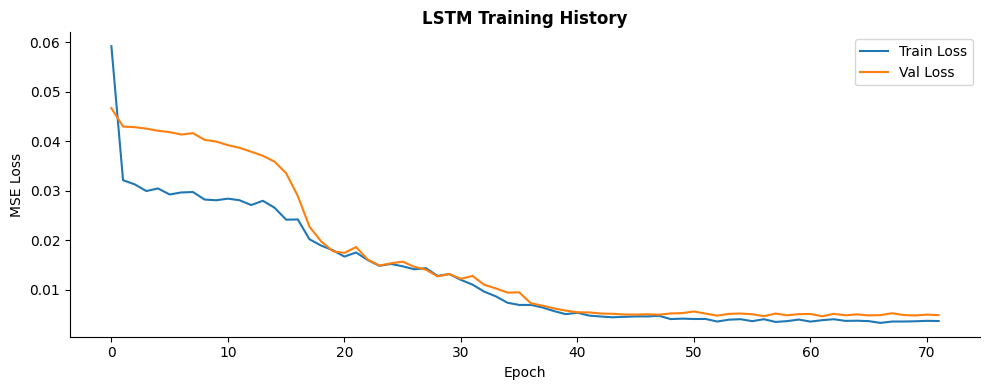

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history_lstm = model.fit(
    X_tr, y_tr,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

# Plot training history
plt.figure(figsize=(10, 4))
plt.plot(history_lstm.history['loss'], label='Train Loss')
plt.plot(history_lstm.history['val_loss'], label='Val Loss')
plt.title('LSTM Training History', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.tight_layout()
plt.show()

### 4c. LSTM Predictions & MAPE

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
LSTM MAPE : 8.54%
LSTM RMSE : 740.35
Assessment: ✅ Excellent – MAPE < 10%, high accuracy


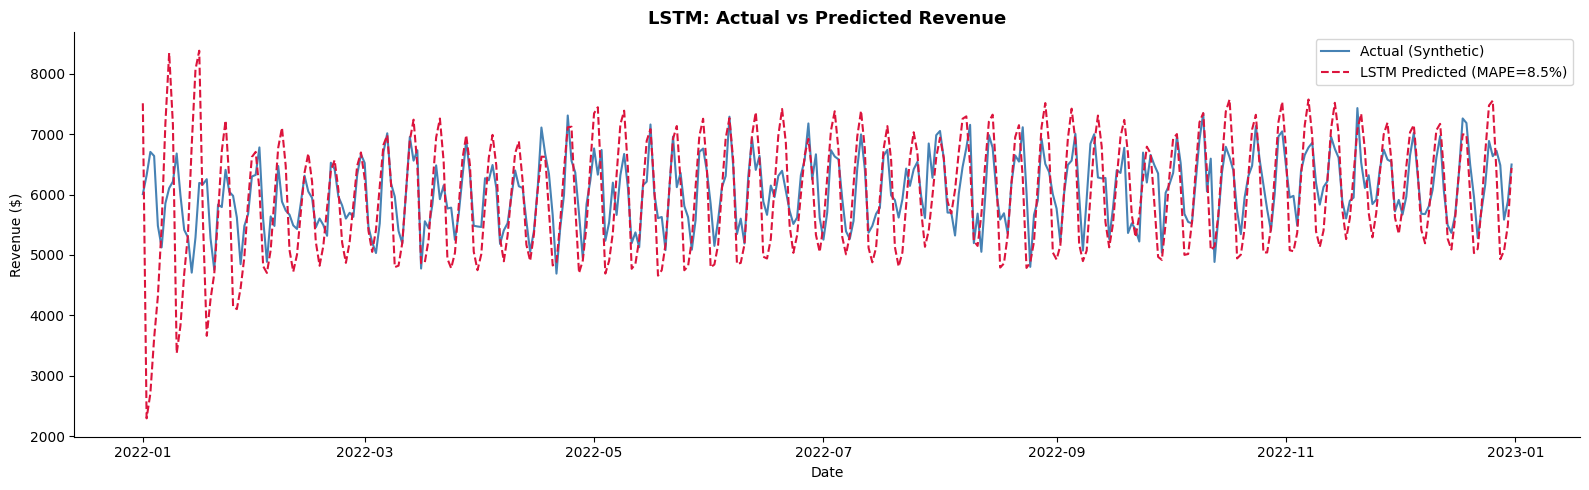

In [ ]:
# Predict on test set
lstm_preds_scaled = model.predict(X_te)
lstm_preds = scaler.inverse_transform(lstm_preds_scaled).flatten()
lstm_actual = scaler.inverse_transform(y_te.reshape(-1, 1)).flatten()

# MAPE
def mape(actual, predicted):
    actual, predicted = np.array(actual), np.array(predicted)
    mask = actual != 0
    return np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100

lstm_mape = mape(lstm_actual, lstm_preds)
lstm_rmse_val = np.sqrt(mean_squared_error(lstm_actual, lstm_preds))

print(f'LSTM MAPE : {lstm_mape:.2f}%')
print(f'LSTM RMSE : {lstm_rmse_val:.2f}')

if lstm_mape < 10:
    comment = '✅ Excellent – MAPE < 10%, high accuracy'
elif lstm_mape < 20:
    comment = '✅ Good – MAPE < 20%, acceptable for business forecasting'
elif lstm_mape < 30:
    comment = '⚠️ Fair – MAPE 20-30%, some error but usable'
else:
    comment = '❌ Poor – MAPE > 30%, model needs improvement'
print(f'Assessment: {comment}')

# Plot
test_dates = full_series['date'].values[n_train:]

plt.figure(figsize=(16, 5))
plt.plot(test_dates, lstm_actual, label='Actual (Synthetic)', color='steelblue', linewidth=1.5)
plt.plot(test_dates, lstm_preds,  label=f'LSTM Predicted (MAPE={lstm_mape:.1f}%)',
         color='crimson', linewidth=1.5, linestyle='--')
plt.title('LSTM: Actual vs Predicted Revenue', fontsize=13, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Revenue ($)')
plt.legend()
plt.tight_layout()
plt.show()

### 4d. LSTM Trained on Full Series → 3-Month Forecast

In [ ]:
# Retrain on full series
X_full, y_full = create_sequences(scaled, SEQ_LEN)
X_full = X_full.reshape(X_full.shape[0], X_full.shape[1], 1)

tf.random.set_seed(42)
model_full = Sequential([
    LSTM(64, return_sequences=True, input_shape=(SEQ_LEN, 1)),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])
model_full.compile(optimizer='adam', loss='mse')

early_stop2 = EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)
model_full.fit(X_full, y_full, epochs=100, batch_size=32, callbacks=[early_stop2], verbose=0)
print('✅ Full-series LSTM training complete')

✅ Full-series LSTM training complete


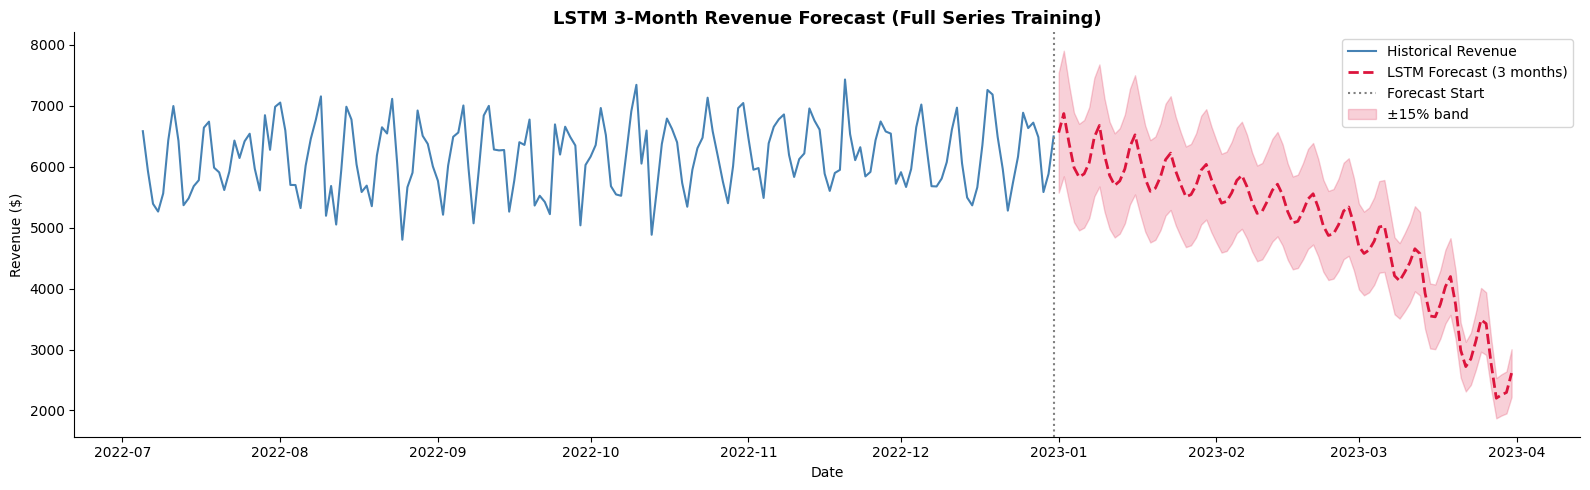

Forecasted total revenue for next 3 months: $453,790.34
Average daily revenue forecast: $5,042.11


In [ ]:
# Iterative 3-month (90-day) forecast
N_FORECAST = 90
last_sequence = scaled[-SEQ_LEN:].copy()
future_rev_preds = []

for _ in range(N_FORECAST):
    inp = last_sequence.reshape(1, SEQ_LEN, 1)
    pred_scaled = model_full.predict(inp, verbose=0)[0, 0]
    future_rev_preds.append(pred_scaled)
    last_sequence = np.append(last_sequence[1:], [[pred_scaled]], axis=0)

future_rev = scaler.inverse_transform(np.array(future_rev_preds).reshape(-1, 1)).flatten()
future_rev = np.clip(future_rev, 0, None)

forecast_dates_3m = pd.date_range(full_series['date'].max() + pd.Timedelta(days=1), periods=N_FORECAST)
forecast_3m_df = pd.DataFrame({'date': forecast_dates_3m, 'forecast_revenue': future_rev})

# Plot
recent_rev = full_series.tail(180)
plt.figure(figsize=(16, 5))
plt.plot(recent_rev['date'], recent_rev['sales_amount'], label='Historical Revenue', color='steelblue', linewidth=1.5)
plt.plot(forecast_3m_df['date'], forecast_3m_df['forecast_revenue'],
         label='LSTM Forecast (3 months)', color='crimson', linewidth=2, linestyle='--')
plt.axvline(full_series['date'].max(), color='gray', linestyle=':', linewidth=1.5, label='Forecast Start')
plt.fill_between(forecast_3m_df['date'], forecast_3m_df['forecast_revenue'] * 0.85,
                 forecast_3m_df['forecast_revenue'] * 1.15, alpha=0.2, color='crimson', label='±15% band')
plt.title('LSTM 3-Month Revenue Forecast (Full Series Training)', fontsize=13, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Revenue ($)')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Forecasted total revenue for next 3 months: ${forecast_3m_df["forecast_revenue"].sum():,.2f}')
print(f'Average daily revenue forecast: ${forecast_3m_df["forecast_revenue"].mean():,.2f}')

---
## 📋 Summary of Results

In [ ]:
print('=' * 55)
print('         AIML CAPSTONE — FINAL SUMMARY')
print('=' * 55)

print('\n🔍 PRELIMINARY ANALYSIS')
print(f'  • Restaurants : {len(restaurants)}')
print(f'  • Items       : {len(items)}')
print(f'  • Sales rows  : {len(sales):,}')
print(f'  • Date range  : {sales["date"].min().date()} → {sales["date"].max().date()}')

print('\n🏆 TOP PERFORMERS')
print(f'  • Best restaurant (volume)  : {store_volume.idxmax()}')
print(f'  • Best restaurant (revenue) : {store_daily_rev.idxmax()}')
print(f'  • Most popular item overall : {item_sales.groupby("name_item")["item_count"].sum().idxmax()}')

print('\n🤖 ML MODEL PERFORMANCE (RMSE — lower is better)')
for _, row in results.iterrows():
    marker = '🥇' if row['Model'] == best_model_name else '  '
    print(f'  {marker} {row["Model"]:<22}: {row["RMSE"]:.2f}')

print('\n🧠 LSTM DEEP LEARNING')
print(f'  • MAPE  : {lstm_mape:.2f}%')
print(f'  • RMSE  : {lstm_rmse_val:.2f}')
print(f'  • 3-Month Revenue Forecast: ${forecast_3m_df["forecast_revenue"].sum():,.2f}')
print('\n' + '=' * 55)

         AIML CAPSTONE — FINAL SUMMARY

🔍 PRELIMINARY ANALYSIS
  • Restaurants : 6
  • Items       : 100
  • Sales rows  : 109,600
  • Date range  : 2019-01-01 → 2021-12-31

🏆 TOP PERFORMERS
  • Best restaurant (volume)  : Bob's Diner
  • Best restaurant (revenue) : Bob's Diner
  • Most popular item overall : Strawberry Smoothy

🤖 ML MODEL PERFORMANCE (RMSE — lower is better)
  🥇 XGBoost               : 57.83
     Random Forest         : 59.67
     Linear Regression     : 59.95

🧠 LSTM DEEP LEARNING
  • MAPE  : 8.54%
  • RMSE  : 740.35
  • 3-Month Revenue Forecast: $453,790.34

